# 7.3.2 线性高斯预测与观测更新

## 学习目标与先修知识

从条件高斯推导Kalman递推，检验时刻约定与缺测分支。

先修：7.3.1的条件高斯，7.1的有噪状态（state）模型（model）。 [本篇学习次序](../README.md)。

## 具体问题

如果一天只到达一个第一室读数，怎样持续修正两室估计，同时保存“不确定到什么程度”？我们把上节一次条件化重复使用在动态系统上。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]

## 初步实验

In [2]:
P=4.;R=1.;K=P/(P+R)
print('首步增益=',K,'均值=',K*2,'方差=',(1-K)*P)

首步增益= 0.8 均值= 1.6 方差= 0.7999999999999998


## 模型假设

F、H、Q、R已知。初态 $x_0$ 服从高斯分布（Gaussian distribution），并与所有过程噪声（process noise）$w_t$ 和测量噪声（measurement noise）$v_t$ 独立；两类噪声均为零均值高斯，协方差（covariance）分别为 Q、R，不同时刻及不同类别的噪声彼此独立。单位与7.1相同，状态是有符号偏差。R严格正，创新的方差（variance）S在本节是正标量，更新所需除法因此有定义。缺测机制外生；模型参数（parameter）误差不由公式自动吸收。

## 数学解释与推导

由线性传播得到预测矩
$$m_t^-=Fm_{t-1},\quad P_t^-=FP_{t-1}F^T+Q.$$
观测（observation）预测为 $Hm_t^-$；创新（innovation）$r_t=y_t-Hm_t^-$。状态与读数的交叉协方差（covariance）为 $C_t=P_t^-H^T$，读数方差为 $S_t=HP_t^-H^T+R$。代入条件高斯公式：
$$K_t=P_t^-H^TS_t^{-1},\quad m_t=m_t^-+K_tr_t,\quad P_t=P_t^--K_tS_tK_t^T.$$
这就是卡尔曼滤波（Kalman filtering，KF）。从误差 $(I-KH)(x-m^-)-Kv$ 展开还能得到Joseph形式
$$P_t=(I-KH)P_t^-(I-KH)^T+K R K^T.$$
它和上式数学等价，不能遗漏末项。初值（initial condition）规定为时刻0的观测前矩，所以首个读数之前不多做一次F预测。缺测时 $m_t=m_t^-,P_t=P_t^-$。

## 核心实现

下面按推导写出计算步骤；函数的输入（input）只包含模型与当时可用的信息。

In [3]:
def kalman_filter(transition, sensor, process_covariance, measurement_variance,
                  initial_mean, initial_covariance, observations):
    F, H, Q = map(lambda x: np.array(x, float), (transition, sensor, process_covariance))
    mean, covariance = np.array(initial_mean, float), np.array(initial_covariance, float)
    result = dict(predicted_means=[], predicted_covariances=[], means=[], covariances=[], innovations=[], innovation_variances=[])
    for t, observed in enumerate(observations):
        if t:
            mean, covariance = F @ mean, F @ covariance @ F.T + Q
        result['predicted_means'].append(mean.tolist())
        result['predicted_covariances'].append(covariance.tolist())
        innovation_variance = float(H @ covariance @ H + measurement_variance)
        innovation = None if observed is None else float(observed - H @ mean)
        if observed is not None:
            gain = covariance @ H / innovation_variance
            mean = mean + gain * innovation
            # Joseph形式保留测量噪声项；数学上等于P-KSKᵀ。
            residual_map = np.eye(len(mean)) - np.outer(gain, H)
            covariance = residual_map @ covariance @ residual_map.T + np.outer(gain, gain) * measurement_variance
            covariance = (covariance + covariance.T) / 2
        result['means'].append(mean.tolist())
        result['covariances'].append(covariance.tolist())
        result['innovations'].append(innovation)
        result['innovation_variances'].append(innovation_variance)
    return result

## 对照实验

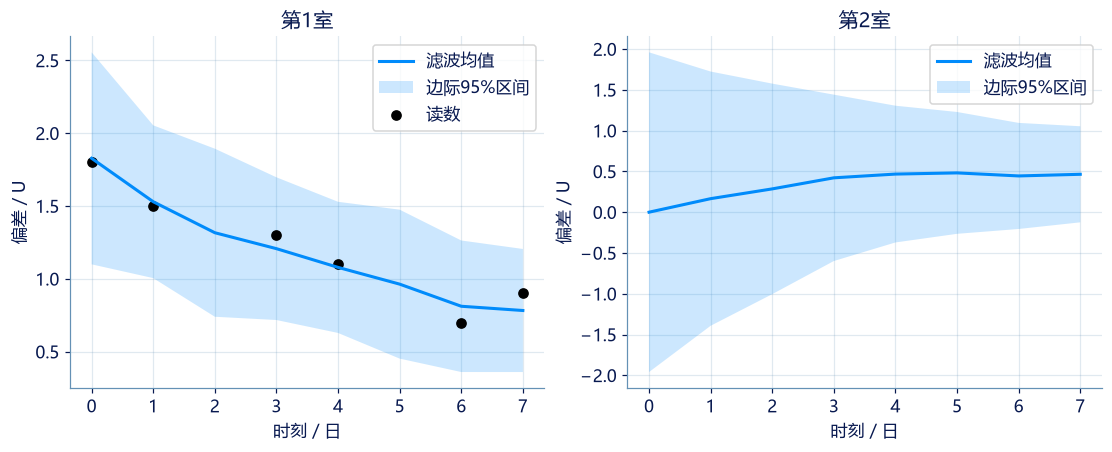

In [4]:
F=np.array([[.85,.1],[.1,.8]]);H=np.array([1.,0.]);Q=np.eye(2)*.02;R=.16;m0=np.array([2.,0.]);P0=np.eye(2)
observed=[1.8,1.5,None,1.3,1.1,None,.7,.9]
run=kalman_filter(F,H,Q,R,m0,P0,observed);mean=np.array(run['means']);cov=np.array(run['covariances']);t=np.arange(len(observed))
fig,axes=plt.subplots(1,2,figsize=(10,4),sharex=True)
for i,ax in enumerate(axes):
    sd=np.sqrt(cov[:,i,i]);ax.plot(t,mean[:,i],label='滤波均值');ax.fill_between(t,mean[:,i]-1.96*sd,mean[:,i]+1.96*sd,alpha=.2,label='边际95%区间');ax.set(xlabel='时刻 / 日',ylabel='偏差 / U',title=f'第{i+1}室');ax.legend()
axes[0].scatter(t,[np.nan if y is None else y for y in observed],color='black',label='读数');axes[0].legend();plt.show()

### 独立核验与边界

In [5]:
# 独立建立x0与y0的联合高斯，不调用递推来核对首步。
S=H@P0@H+R;expected=m0+P0@H/S*(observed[0]-H@m0)
np.testing.assert_allclose(mean[0],expected)
np.testing.assert_allclose(run['means'][2],run['predicted_means'][2])
for P in cov:
    np.testing.assert_allclose(P,P.T,atol=1e-12);assert np.linalg.eigvalsh(P).min()>0
future=kalman_filter(F,H,Q,R,m0,P0,observed[:3]+[99.]*5)
np.testing.assert_allclose(future['means'][:3],mean[:3])
assert kalman_filter(F,H,Q,R,m0,P0,[])['means']==[]
print('首步条件分布、缺测、半正定和在线前缀检查通过。')

首步条件分布、缺测、半正定和在线前缀检查通过。


## 结果解释

未直接观测的第二室依靠动态交换和先验（prior）相关获得信息。缺测时仍进行预测：F 的收缩与 Q 的补充共同决定区间变宽还是变窄。整段联合高斯核验在本篇末节展开。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：线性高斯递推

已知一维或二维线性模型（model），传感器每次给出一个标量读数。返回滤波均值和协方差（covariance）；状态（state）真值不作为输入（input）。 初态为给定均值和协方差的高斯分布（Gaussian distribution）；过程噪声（process noise）w~N(0,Q)、测量噪声（measurement noise）v~N(0,R)，初态及各时刻两种噪声相互独立。

**函数与代码模板**

```python
def solve(
    transition: list[list[float]],
    sensor: list[float],
    process_covariance: list[list[float]],
    measurement_variance: float,
    initial_mean: list[float],
    initial_covariance: list[list[float]],
    observations: list[float | None],
) -> tuple[list[list[float]], list[list[list[float]]]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `transition` | `list[list[float]]` | 已知状态转移矩阵（transition matrix） F。 | 无量纲 |
| `sensor` | `list[float]` | 标量读数的观测（observation）行 H。 | 无量纲 |
| `process_covariance` | `list[list[float]]` | 一步过程噪声协方差 Q。 | U² |
| `measurement_variance` | `float` | 测量噪声方差（variance） R。 | U² |
| `initial_mean` | `list[float]` | 时刻 0 观测前均值。 | U |
| `initial_covariance` | `list[list[float]]` | 时刻 0 观测前协方差。 | U² |
| `observations` | <code>list[float &#124; None]</code> | 从时刻 0 开始的读数；None 为缺测。 | U |

**返回值**

按以下顺序返回元组：(means, covariances)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `means` | `list[list[float]]` | 各时刻使用当时可用观测后的均值。 | U |
| `covariances` | `list[list[list[float]]]` | 与 means 对应的协方差矩阵（covariance matrix）。 | U² |

**计算规则**

时刻0直接由initial_mean/initial_covariance进行观测更新；t>0先m=F m、P=F P Fᵀ+Q。非缺测时S=H P Hᵀ+R，K=P Hᵀ/S，m=m+K(y−H m)，P=P−K S Kᵀ。None只保留预测。

**约束与边界**

- 状态维数1或2，观测长度0—20；R>0，Q半正定（positive semidefinite），初始P正定（positive definite）。
- H是一维列表；全部数值有限，绝对值≤100；返回数组（array）不包含初值（initial condition）之外额外的时刻。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| transition | 已知状态转移矩阵（transition matrix） F。 | [[1.0]] | 无量纲 |
| sensor | 标量读数的观测（observation）行 H。 | [1.0] | 无量纲 |
| process_covariance | 一步过程噪声协方差 Q。 | [[0.1]] | U² |
| measurement_variance | 测量噪声方差（variance） R。 | 1 | U² |
| initial_mean | 时刻 0 观测前均值。 | [0.0] | U |
| initial_covariance | 时刻 0 观测前协方差。 | [[4.0]] | U² |
| observations | 从时刻 0 开始的读数；None 为缺测。 | [2.0, None, 1.0] | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
transition = [[1.0]]
sensor = [1.0]
process_covariance = [[0.1]]
measurement_variance = 1.0
initial_mean = [0.0]
initial_covariance = [[4.0]]
observations = [2.0, None, 1.0]

result = solve(transition, sensor, process_covariance, measurement_variance, initial_mean, initial_covariance, observations)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| means | 各时刻使用当时可用观测后的均值。 | [[1.6], [1.6], [1.3]] | U |
| covariances | 与 means 对应的协方差矩阵（covariance matrix）。 | [[[0.7999999999999998]], [[0.8999999999999998]], [[0.49999999999999994]]] | U² |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[1.6], [1.6], [1.3]],
                   [[[0.7999999999999998]],
                    [[0.8999999999999998]],
                    [[0.49999999999999994]]])
```

**样例解释**

第一步更新初始先验（prior），均值1.6、方差0.8；第二步缺测，均值仍1.6但方差增加到0.9。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：线性高斯递推](http://127.0.0.1:8000/chapters/07-03-%E5%8D%A1%E5%B0%94%E6%9B%BC%E6%BB%A4%E6%B3%A2/practice/?question=p07-kalman-sequence)

### 第 2 题 · 单项选择题：第一步之前要转移吗

本篇 initial_mean 表示时刻0观测（observation）前的均值，observations[0] 表示时刻0读数。哪项正确？

- **A.** 先做一次F转移才开始处理第0个读数。
- **B.** 先直接观测更新；从第1个读数起先预测。
- **C.** 每一步都跳过过程噪声（process noise）。
- **D.** 初始均值等同于精确真实状态（state）。

[作答：第一步之前要转移吗](http://127.0.0.1:8000/chapters/07-03-%E5%8D%A1%E5%B0%94%E6%9B%BC%E6%BB%A4%E6%B3%A2/practice/?question=p07-kalman-timing)

### 第 3 题 · 多项选择题：更新协方差丢了哪一项

将P更新写成(I−KH)P(I−KH)ᵀ，却遗漏K R Kᵀ。哪些正确？

- **A.** 这个式子一般会低估测量带来的不确定性。
- **B.** 只要K非零，遗漏项在R>0时可能非零。
- **C.** 它始终等于P−K S Kᵀ。
- **D.** 补回K R Kᵀ得到Joseph形式。

[作答：更新协方差丢了哪一项](http://127.0.0.1:8000/chapters/07-03-%E5%8D%A1%E5%B0%94%E6%9B%BC%E6%BB%A4%E6%B3%A2/practice/?question=p07-joseph-noise)

### 第 4 题 · 单项选择题：什么时候是精确后验

关于Kalman滤波，哪项陈述最准确？

- **A.** 任何非线性模型（model）中都得到真实后验（posterior）。
- **B.** 线性模型、联合高斯初态和独立高斯噪声的假设成立时，它给出精确滤波分布（distribution）的矩。
- **C.** 协方差（covariance）为零说明现实中没有模型错误。
- **D.** 满列秩（rank）H是所有Kalman更新的必要条件。

[作答：什么时候是精确后验](http://127.0.0.1:8000/chapters/07-03-%E5%8D%A1%E5%B0%94%E6%9B%BC%E6%BB%A4%E6%B3%A2/practice/?question=p07-gaussian-exactness)

### 第 5 题 · 多项选择题：无读数与连续缺测

本章计算题 solve 契约中，哪些正确？

- **A.** 空observations返回两个空列表。
- **B.** [None,None]仍产生两时刻的估计结果。
- **C.** None等价于观测（observation）到零。
- **D.** 缺测时协方差（covariance）按动态预测变化。

[作答：无读数与连续缺测](http://127.0.0.1:8000/chapters/07-03-%E5%8D%A1%E5%B0%94%E6%9B%BC%E6%BB%A4%E6%B3%A2/practice/?question=p07-empty-observations)

### 延伸阅读

R26，第6章线性Gaussian滤波；R09，估计思想。 [Särkkä 与 Svensson，《Bayesian Filtering and Smoothing》第二版，2023](https://users.aalto.fi/~ssarkka/pub/bfs_book_2023_online.pdf)。本节公式、实现和核验可独立阅读；参考资料用于进一步学习。

[概念探索与交互](http://127.0.0.1:8000/chapters/07-03-卡尔曼滤波/explore/) · [本篇目录](../README.md)